# Task description

Реалізувати:
- алгоритм виявлення розкладань графічним методом
- апостеріорний алгоритм Бродського – Дарховського

# Init

In [1]:
from abc import ABC, abstractmethod
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

from time_series import TimeSeries

In [2]:
class ChangePointDetector(ABC):
    @abstractmethod
    def detect(self, series: np.ndarray) -> int:
        pass


class GraphicalChangePointDetector(ChangePointDetector):
    def __init__(self):
        self.s = None
        self.tau = None

    def detect(self, series: np.ndarray) -> int:
        mean = np.mean(series)
        self.s = np.cumsum(series - mean)
        self.tau = np.argmax(np.abs(self.s))
        return self.tau

    def plot(self, series: np.ndarray, times: Optional[np.ndarray] = None):
        if self.s is None:
            raise RuntimeError("Run detect() first.")

        if times is None:
            times = np.arange(len(series))

        plt.figure(figsize=(10, 4))
        plt.plot(times, self.s, label="CUSUM", color='blue')
        plt.axvline(times[self.tau], color='red', linestyle='--', label=f'Max deviation @ {self.tau}')
        plt.title("Graphical method: Cumulative Sum of Deviations")
        plt.xlabel("Time")
        plt.grid(True)
        plt.legend()
        plt.show()


class BrodskyDarkhovskyDetector(ChangePointDetector):
    def __init__(self, min_distance: int = 10):
        self.min_distance = min_distance

    def detect(self, series: np.ndarray) -> int:
        n = len(series)
        max_stat = -np.inf
        change_point = -1

        for tau in range(self.min_distance, n - self.min_distance):
            left_mean = np.mean(series[:tau])
            right_mean = np.mean(series[tau:])
            stat = abs(left_mean - right_mean)

            if stat > max_stat:
                max_stat = stat
                change_point = tau

        return change_point

# Analyses

## Extract time series

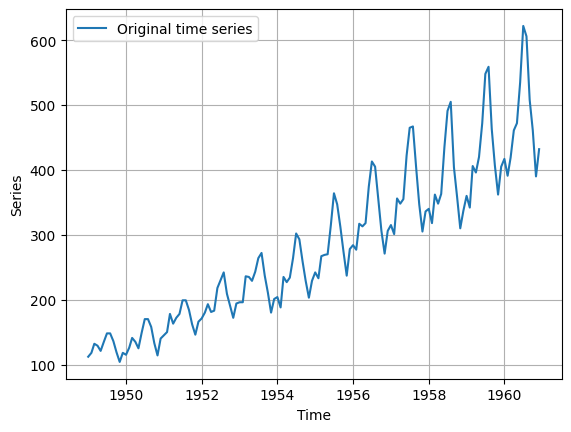

In [3]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original time series")

## Graphical Change Point

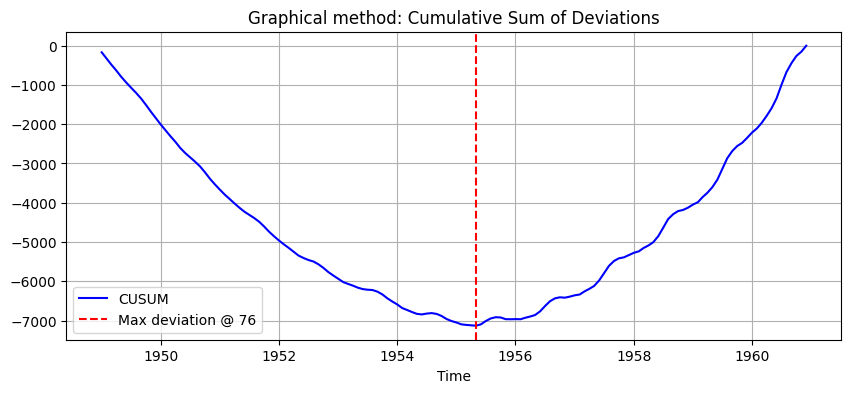

In [6]:
graphical = GraphicalChangePointDetector()

checkpoint = graphical.detect(ts.series)
graphical.plot(ts.series, ts.times)

In [7]:
%store checkpoint

Stored 'checkpoint' (int64)


## Brodsky-Darkhovsky Detector


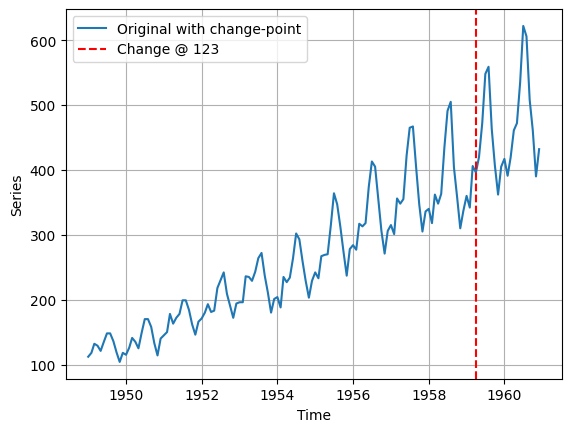

In [7]:
detector = BrodskyDarkhovskyDetector(min_distance=20)
tau = detector.detect(ts.series)
ts.plot_series(changepoint=tau, label="Original with change-point")